In [1]:
import sys
import os
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np

import seaborn as sns
sns.set_style('darkgrid')

from src.Market_v2 import Market

In [3]:
from joblib import dump, load

market = load(project_root / "results/market_simulation_final_2.joblib")
market_model = load(project_root / 'results/market_model_GJR.joblib')

In [11]:
#base_w=np.array([.35, .25, .2, .2]) # try less vol_premia and more sector, makes sense to have less vol premia
market = Market(20, 3, market_model, rf = 0.0001, market_scale_arch=100, random_seed=42, base_w=np.array([.35, .15, .3, .2]))

In [13]:
import src.utils
from importlib import reload
reload(src.utils)
from src.utils import make_scenario, generate_scenarios

In [4]:
N = 20 # n_assets
T = 5 # n_timeperiods - the amount the model sees ahead
K = 100 # n_scenarios

freq = 'weekly'
rf = market.rf

n_steps = 52
n_simulations = 50

trade_cost = 0.001 # 5bps - 20bps

In [15]:
scenarios = generate_scenarios(K, T, N, 'weekly', market)

## MPC

In [5]:
import src.MPCController
from importlib import reload
reload(src.MPCController)
from src.MPCController import MPCController

from src.utils import simulate_target_weight_portfolio

In [17]:
controller = MPCController(K, T, N, risk_free=rf, risk=0.5, trade=trade_cost, risk_type='semi_variance', cvar_alpha=0.90)

In [18]:
controller.is_QP_and_DPP()

(True, True)

In [15]:
from tqdm.notebook import tqdm
import time

for i in tqdm(range(5), desc='Outer'):
    for j in tqdm(range(10), desc='Inner', leave=False):
        time.sleep(.2)

Outer:   0%|          | 0/5 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

Inner:   0%|          | 0/10 [00:00<?, ?it/s]

In [7]:
import src.simulation_generation
from importlib import reload
reload(src.simulation_generation)
from src.simulation_generation import generate_dataset, load_simulation

In [20]:
from src.simulation_generation import generate_dataset

# NOTE: This will OVERWRITE existing dataset.

generate_dataset(n_simulations, n_steps, freq, market, K,T,N, project_root / "datasets/test")

In [107]:
actual_traj, market_return, context = load_simulation(project_root / 'datasets/trial_3asset20idio', 0)

In [109]:
from src.utils import FREQ_COEFF
MAGIC_NUMBER = 20

In [111]:
from tqdm.notebook import tqdm
import warnings

full_stats = []
dataset_path = project_root / 'datasets/trial_3asset20idio'

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning)

    x_init = [100] + [0 for _ in range(N)]

    MPC_sims = np.zeros((n_simulations, n_steps+1, N+1)) # + initial value
    market_sims = np.zeros((n_simulations, n_steps+1))
    eq_sims = np.zeros((n_simulations, n_steps+1, N+1))

    for i in tqdm(range(n_simulations), desc='Simulations'):

        full_stats.append([])

        actual_traj, market_return, context = load_simulation(dataset_path, i)
        full_date_index = context['market'].index

        MPC_sim = [x_init]

        for step in tqdm(range(n_steps), desc=f'simulation {i+1}', leave=False):

            next_date = actual_traj.index[step+1]
            current_date = actual_traj.index[step]

            current_loc = full_date_index.get_loc(current_date)

            start, end = full_date_index[current_loc - MAGIC_NUMBER + 1], full_date_index[current_loc] # loc is exclusive

            scenarios = generate_scenarios(K ,T, N, freq, market, burn=0,
                                           initial_market_returns=context['market'].loc[start:end],
                                           initial_market_vols=context['market_vol'].loc[start:end], 
                                           initial_sector_returns=context['sectors'].loc[start:end].to_numpy())
            
            controller.update_parameters(scenarios, MPC_sim[-1])
            stats = controller.solve(solver='SCS')
            u0 = controller.control()

            x_next = (MPC_sim[-1] + u0) * np.hstack([1+rf, 1+actual_traj.loc[next_date]])

            MPC_sim.append(x_next)

            full_stats[i].append(stats)

        MPC_sims[i] = np.array(MPC_sim)
        market_sims[i] = np.exp(np.concat([[0], market_return[1:]])).cumprod() * 100
        eq_sims[i] = simulate_target_weight_portfolio(x_init, [0] + [1/N for _ in range(N)], rf, actual_traj.iloc[1:].T, trading_cost=trade_cost)

Simulations:   0%|          | 0/50 [00:00<?, ?it/s]

simulation 1:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 2:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 3:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 4:   0%|          | 0/52 [00:00<?, ?it/s]

...

simulation 18:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 19:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 20:   0%|          | 0/52 [00:00<?, ?it/s]

simulation 21:   0%|          | 0/52 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [13]:
dump(full_stats, project_root / "results/stats/SCS_idio20_3assets.joblib")

['C:\\Users\\lovas\\Desktop\\Szakdoga\\code\\results\\stats\\SCS_idio20_3assets.joblib']

In [13]:
market_sims = np.zeros((n_simulations, n_steps+1))
eq_sims = np.zeros((n_simulations, n_steps+1, N+1))

x_init = [100] + [0 for _ in range(N)]

for i in range(n_simulations):
    actual_traj, market_return, _ = load_simulation(project_root / "datasets/test", i)
    
    market_sims[i] = np.exp(np.concat([[0], market_return])).cumprod() * 100
    eq_sims[i] = simulate_target_weight_portfolio(x_init, [0] + [1/N for _ in range(N)], rf, pd.DataFrame(actual_traj.T), trading_cost=trade_cost)

In [17]:
dump(market_sims, project_root / 'results/test/semivar_test_market.joblib')
dump(eq_sims, project_root / 'results/test/semivar_test_eq.joblib')

['C:\\Users\\lovas\\Desktop\\Szakdoga\\code\\results\\test\\semivar_test_eq.joblib']

## Results

In [61]:
from joblib import dump
dump(MPC_sims, project_root / "results/idio_20/MPC_sims_3asset_semivar.joblib")
dump(market_sims, project_root / "results/idio_20/market_sims_3asset_semivar.joblib")
dump(eq_sims, project_root / "results/idio_20/eq_sims_3asset_semivar.joblib")

['C:\\Users\\lovas\\Desktop\\Szakdoga\\code\\results\\idio_20\\eq_sims_3asset_semivar.joblib']

In [38]:
from joblib import load
MPC_sims = load(project_root / "results/test/semi_var_test_sims.joblib")
market_sims = load(project_root / 'results/test/semivar_test_market.joblib')
eq_sims = load(project_root / 'results/test/semivar_test_eq.joblib')

In [19]:
market = load(project_root / "datasets/test/market.joblib")

In [20]:
df = pd.DataFrame(MPC_sims[0]) # 36, 48 is interesting too in var
eq_df = pd.DataFrame(eq_sims[0])

In [21]:
np.linalg.norm(MPC_sims, 2, axis=(1,2))

array([593.00388597, 568.32822156, 453.32934645, 434.0886032 ,
       829.12276867, 442.97948618, 430.30407504, 632.89082731,
       732.97776765, 407.38809578, 616.5918596 , 476.41474245,
       407.67015026, 688.43379763, 729.11906966, 509.07720779,
       385.58029121, 566.53167358, 421.18492861, 473.30874754,
       590.80368902, 687.16754576, 571.79751116, 437.2316579 ,
       461.82261229, 753.81918959, 458.36724599, 526.58845382,
       393.47447961, 448.23837273, 492.2953972 , 890.69976705,
       522.98387585, 454.72838541, 512.24113989, 709.53121165,
       671.36260736, 395.7400016 , 436.10880871, 535.35134754,
       456.30572528, 594.97610332, 476.23714428, 426.06915802,
       372.45013568, 573.76502232, 319.31655082, 704.85588314,
       467.92210503, 433.91352059])

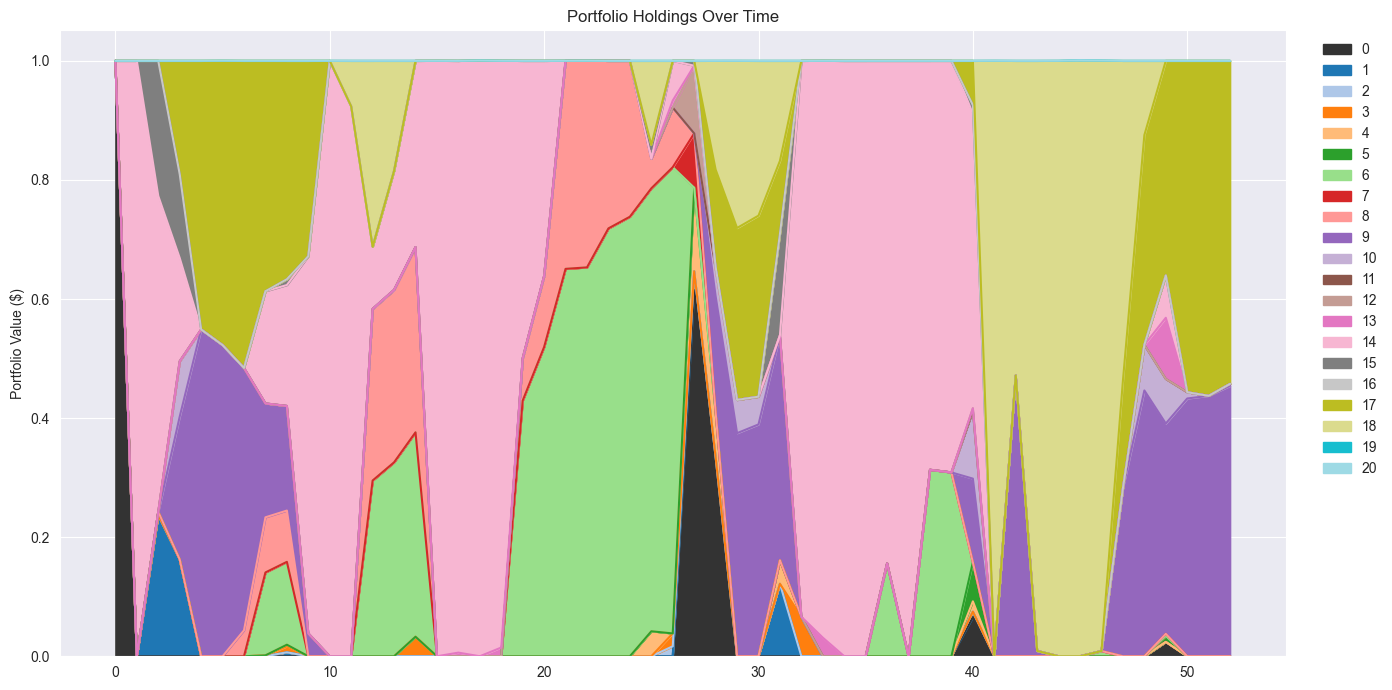

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# all except cash
asset_colors = sns.color_palette("tab20", market.n_assets)

# add cash color at the start
colors =  [(0.2, 0.2, 0.2)] + asset_colors

weights = df.div(df.sum(axis=1), axis=0)
weights[weights < 0] = 0

ax = weights.plot.area(
    figsize=(14, 7),
    #cmap=cmap
    color=colors
)

ax.set_ylabel("Portfolio Value ($)")
ax.set_title("Portfolio Holdings Over Time")

plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=False
)

plt.tight_layout()
plt.show()

In [23]:
sector_holdings = pd.DataFrame()

sector_holdings['cash'] = df[0]
df_ = df.drop(0, axis=1)

for sector in range(market.n_sectors):
    sector_holdings[sector] = df_.T.iloc[market.sectors == sector].sum(axis=0)

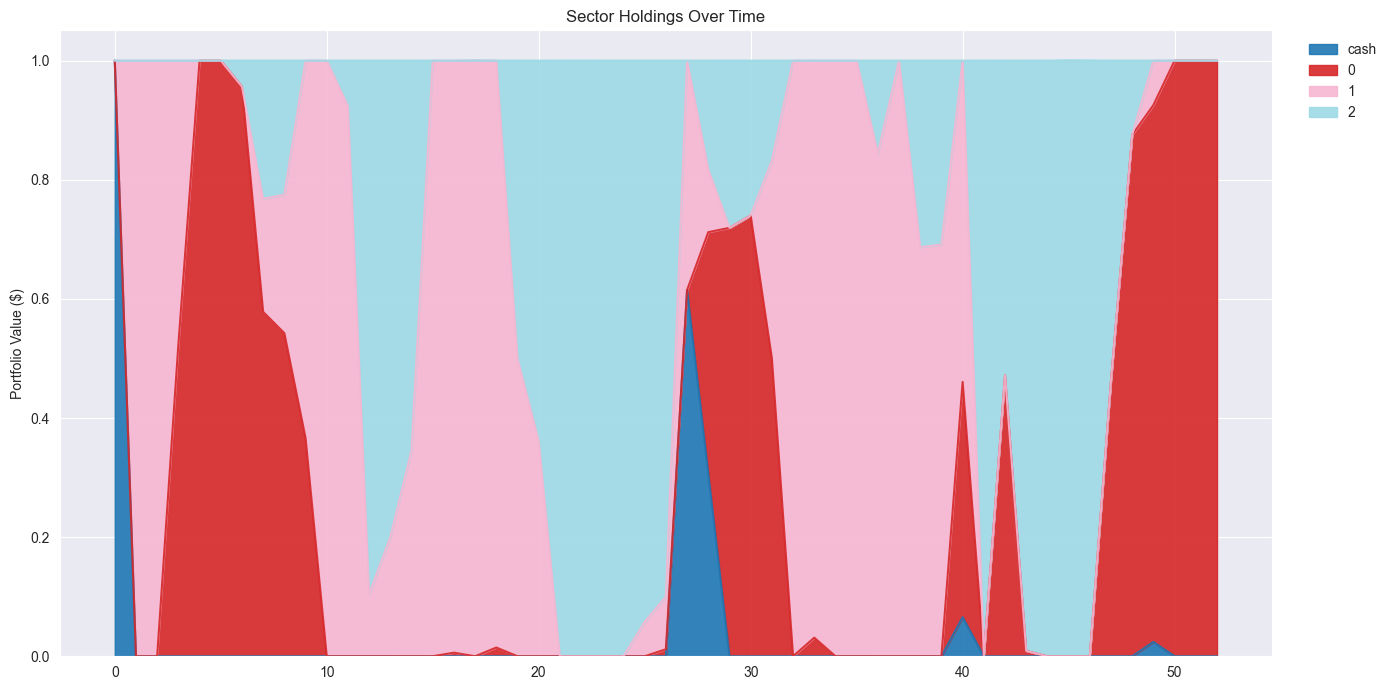

In [24]:
import matplotlib.pyplot as plt

cmap = plt.get_cmap("tab20")

sector_weights = sector_holdings.div(df.sum(axis=1), axis=0)
sector_weights[sector_weights < 0] = 0

ax = sector_weights.plot.area(
    figsize=(14, 7),
    cmap=cmap,
    alpha=0.9
)

ax.set_ylabel("Portfolio Value ($)")
ax.set_title("Sector Holdings Over Time")

plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=False
)

plt.tight_layout()
plt.show()

In [25]:
market.summary()

,alpha,beta,idio vols,sector,sector_coeffs,sector_vols,vol_premium
0,0.000133,0.400702,0.008558,1,0.749911,0.006469,-1.569099
1,0.000026,0.291777,0.006387,2,0.372522,0.009703,1.078958
2,-0.000004,0.358874,0.007180,1,0.646828,0.006469,1.035698
3,0.000212,0.340080,0.006636,1,0.533293,0.006469,-1.170836
4,0.000126,0.313744,0.005866,0,0.354673,0.008772,-1.020555
5,0.000003,0.684706,0.013967,2,0.838939,0.009703,2.364322
6,0.000008,0.225944,0.004546,1,0.402446,0.006469,0.632694
7,-0.000121,0.719096,0.013986,2,0.811356,0.009703,2.038358
8,-0.000009,0.653988,0.013434,0,0.835746,0.008772,-2.482492
9,0.000088,0.512457,0.010544,0,0.715379,0.008772,-1.693856


In [26]:
rm = pd.Series(market_sims[0])

In [27]:
rm = rm.pct_change()
rm = rm - rm.mean()
m_volatility = (rm**2).ewm(span=20, adjust=False).mean()
m_fast = (rm**2).ewm(span=2, adjust=False).mean()

<Axes: >

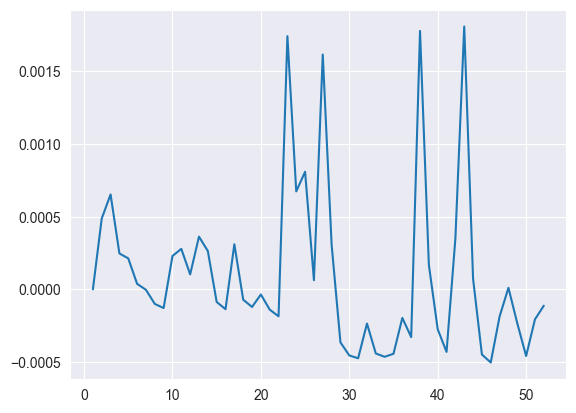

In [28]:
(m_fast - m_volatility).plot()

In [29]:
mm = pd.DataFrame(market_sims[0])

In [30]:
market_sims.std(axis=1)

array([12.5129506 ,  8.29415433,  7.58086832, 11.02278542,  6.89400747,
        4.75961372,  9.84730957, 11.21940418,  7.12404168,  6.81756138,
       10.15253076,  4.58554278,  8.42392728, 13.72325594,  6.14313068,
        9.5984838 ,  4.61828966,  8.88418248,  5.29437805,  4.1944032 ,
        5.48208824, 18.98098278, 10.59665271,  3.75547707, 12.17387604,
        9.18564765, 17.09709917,  8.07327674,  6.19954189,  4.60601107,
        6.63049936,  5.45626208, 10.3835234 ,  9.38878853, 15.29802028,
        6.46758565,  4.46465266, 12.36402353,  9.48534115,  4.18509042,
        9.45823594, 10.45289254,  4.68486205,  9.76868551,  5.23058994,
        4.58947358,  8.76773252,  6.91408257,  5.25522688,  4.33212723])

In [31]:
mm.rename(columns={0: 'market'}, inplace=True)

<Axes: >

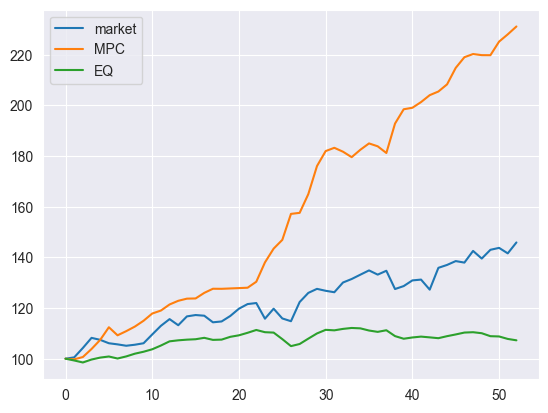

In [32]:
mm.plot(label='market', legend=True)
df.sum(axis=1).plot(label='MPC', legend=True)
eq_df.sum(axis=1).plot(label='EQ', legend=True)


In [33]:
w_ = weights.T.loc[1:]

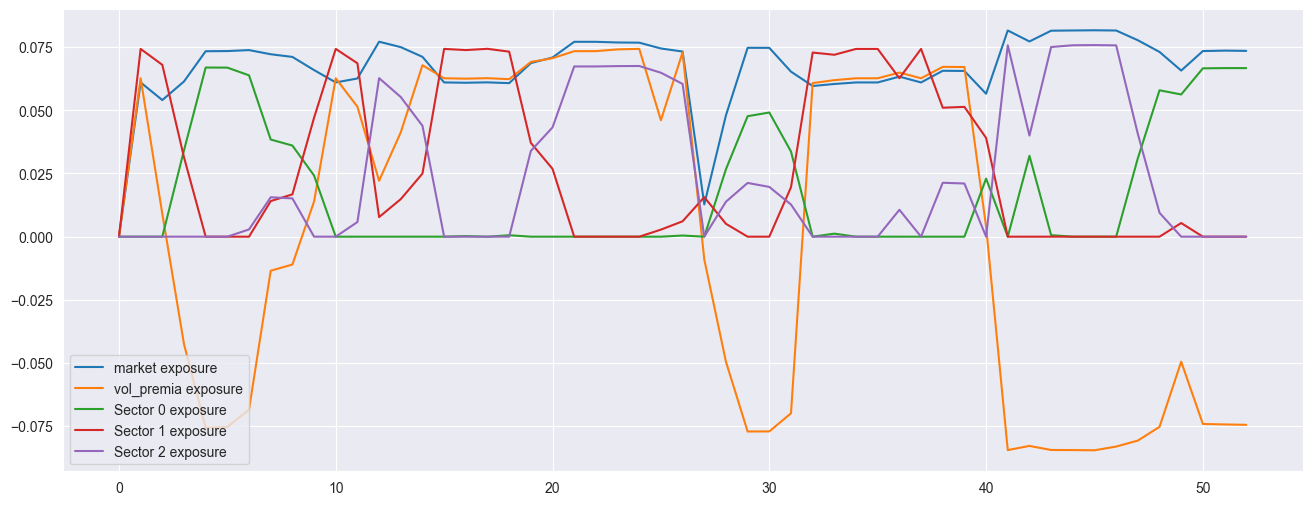

In [34]:
# Plot exposures to factors from coefficients

fig, ax = plt.subplots(1,1, figsize=(16,6))

(weights @ np.hstack([0, market.betas]) / market.betas.sum()).plot(label = 'market exposure', ax=ax)
(weights @ np.hstack([0, market.vol_premia]) / np.linalg.norm(market.vol_premia, 1)).plot(label = 'vol_premia exposure', ax=ax)

sector_exps = []
sector_scale = market.sector_coeffs.sum()

for sector in range(market.n_sectors):
    sector_mask = market.sectors == sector
    sector_exp = market.sector_coeffs[sector_mask] @ w_.iloc[sector_mask]
    sector_exps.append(sector_exp)
    (sector_exp / sector_scale).plot(label = f'Sector {sector} exposure', ax=ax)

ax.legend()

In [39]:
market_sims = pd.DataFrame(market_sims)
MPC_sims = pd.DataFrame(MPC_sims.sum(axis=2))
eq_sims = pd.DataFrame(eq_sims.sum(axis=2))

In [40]:
import src.portfolio_analysis
from importlib import reload
reload(src.portfolio_analysis)

<module 'src.portfolio_analysis' from 'C:\\Users\\lovas\\Desktop\\Szakdoga\\code\\src\\portfolio_analysis.py'>

In [41]:
from src.portfolio_analysis import plot_simulations, compute_returns, compute_metrics

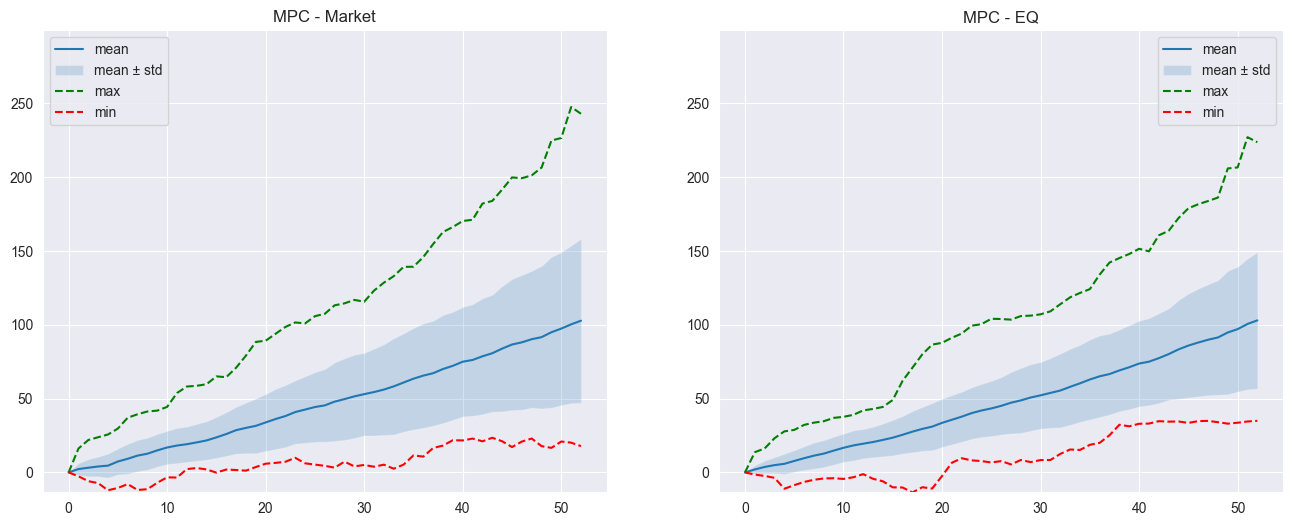

In [42]:
plot_simulations([MPC_sims - market_sims, MPC_sims - eq_sims], labels=["MPC - Market", 'MPC - EQ'])

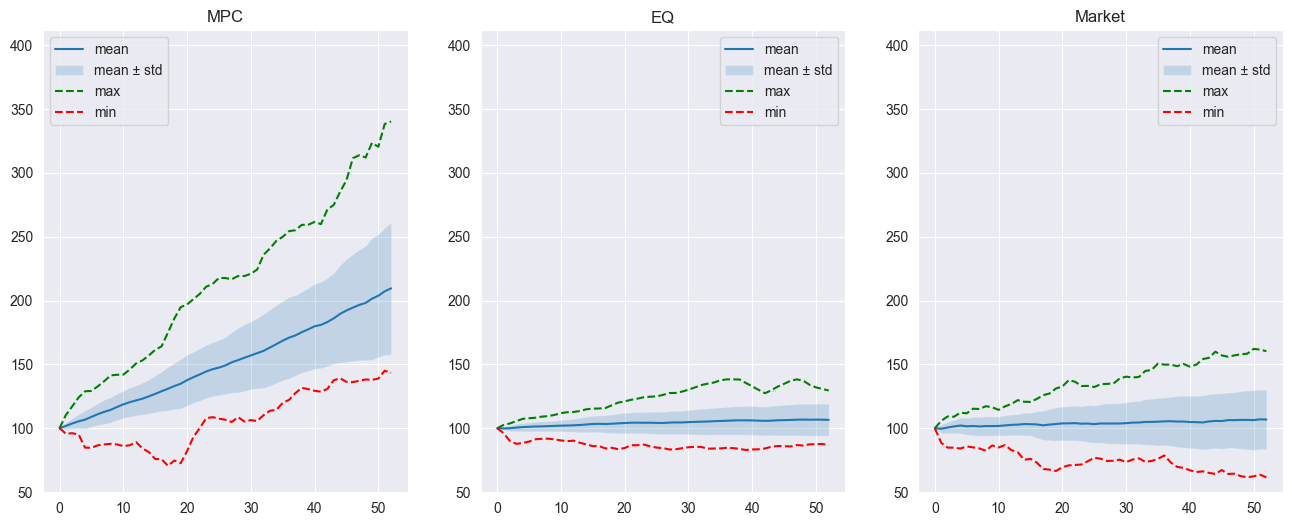

In [43]:
plot_simulations([MPC_sims, eq_sims, market_sims], labels=['MPC', 'EQ', 'Market'])

In [44]:
returns = compute_returns([MPC_sims, eq_sims, market_sims], names=['MPC', 'EQ', 'Market'])

In [45]:
from statsmodels.regression import linear_model
import statsmodels.api as sm

mpc_capm = []
eq_capm = []

for col in returns['MPC'].columns:
    lm = linear_model.OLS(returns['MPC'][col], sm.add_constant(returns['Market'][col])).fit()
    mpc_capm.append(lm)

    lm = linear_model.OLS(returns['EQ'][col], sm.add_constant(returns['Market'][col])).fit()
    eq_capm.append(lm)

In [46]:
capm_coeffs = pd.DataFrame(index=['MPC alpha', 'MPC beta', 'EQ alpha', 'EQ beta'])

for i in range(n_simulations):
    capm_coeffs[i] = np.hstack([mpc_capm[i].params.values, eq_capm[i].params.values])

In [47]:
from src.portfolio_analysis import conf_int_high, conf_int_low, conf_int_p

In [48]:
capm_summary = capm_coeffs.agg(['mean', 'std', 'sem', conf_int_low, conf_int_high, conf_int_p], axis=1)
capm_summary # NOTE: betas are with mean (2 sided), alphas with 0 (greater) (so betas p are not very meaningful)

,mean,std,sem,conf_int_low,conf_int_high,conf_int_p
MPC alpha,0.014197,0.004644,0.000657,0.013096,inf,0.000000
MPC beta,0.111924,0.141977,0.020079,0.071575,0.152273,1.000000
EQ alpha,0.001094,0.001837,0.000260,0.000659,inf,0.000054
EQ beta,0.164195,0.058218,0.008233,0.147650,0.180741,1.000000


In [49]:
market.base_w

array([0.35, 0.15, 0.3 , 0.2 ])

In [50]:
metrics = compute_metrics(returns, rf)
metrics # ADD VaR, CVaR to metrics

,MPC,EQ,Market
mean of mean returns,0.014040,0.001147,0.001162
std of mean returns,0.004568,0.002234,0.004161
se of mean returns,0.000646,0.000316,0.000588
ci_low of mean returns,0.012741,0.000512,-0.000021
ci high of mean returns,0.015338,0.001782,0.002344
mean of sharpe ratios,0.662390,0.131095,0.051676
std of sharpe ratios,0.215885,0.249214,0.170993
se of sharpe ratios,0.030531,0.035244,0.024182
ci_low of sharpe ratios,0.601036,0.060269,0.003080
ci high of sharpe ratios,0.723744,0.201921,0.100272


In [159]:
_, _, context = load_simulation(project_root / 'datasets', 0)

In [70]:
mpc_factor_model = []
mpc_params_df = pd.DataFrame()
eq_params_df = pd.DataFrame()

from src.optimized_functions import ewma_1d, ewma_2d
from src.utils import FREQ_COEFF

dataset_path = project_root / "datasets/test"

for i, col in enumerate(returns['MPC'].columns):
    _, _, context = load_simulation(dataset_path, i)

    market_factor = ewma_1d(context['market'], 20)

    vol_factor = ewma_1d(context['market_vol'], 20)
    vol_factor = context['market_vol'] - vol_factor

    sector_factors = ewma_2d(context['sectors'], 20)

    Factors = np.concatenate([market_factor[:, None], vol_factor[:, None], sector_factors], axis=1)

    Factors = Factors[-52*FREQ_COEFF[freq]:, :]

    Factors = (1+Factors).reshape(52, FREQ_COEFF[freq], market.n_sectors + 2).prod(axis=1)

    Factors = pd.DataFrame(Factors, index=returns['MPC'][col].index)
    Factors.columns = ['Market', 'vol_premia'] + [f"sector {j}" for j in range(market.n_sectors)]

    lm = linear_model.OLS(np.log(1+returns['MPC'][col]), sm.add_constant(Factors)).fit()
    mpc_factor_model.append(lm)

    mpc_params_df[i] = lm.params

    lm = linear_model.OLS(np.log(1+returns['EQ'][col]), sm.add_constant(Factors)).fit()
    eq_params_df[i] = lm.params

In [68]:
sector_factors[[0,1,2]].plot()

AttributeError: 'numpy.ndarray' object has no attribute 'plot'

(-2.0, 1.5)

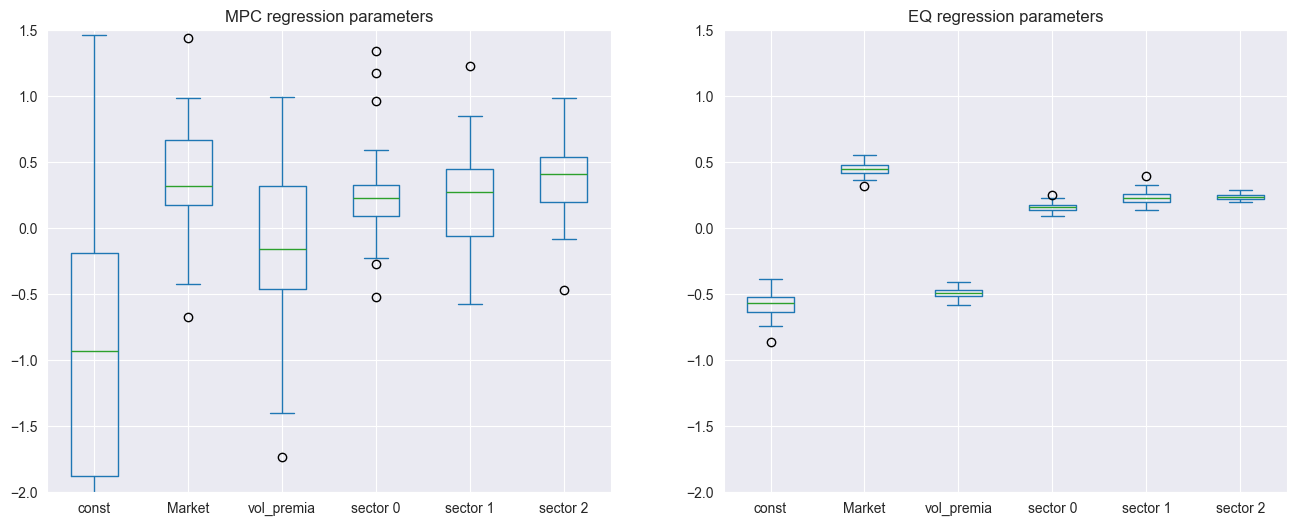

In [71]:
fig, ax = plt.subplots(1,2, figsize=(16,6))

mpc_params_df.T.plot(kind='box', ax=ax[0])
eq_params_df.T.plot(kind='box', ax=ax[1])

ax[0].set_title('MPC regression parameters')
ax[1].set_title('EQ regression parameters')

ax[0].set_ylim(-2, 1.5)
ax[1].set_ylim(-2, 1.5)